## We are using the Resnet-101 model

In [3]:
from torchvision import models
from PIL import Image

import torchvision
import os
import subprocess
import matplotlib.pyplot as plt
import torch
import requests
import time

plt.style.use('ggplot')

# Load the model ResNet101 segmentation

In [4]:
model  = models.segmentation.fcn_resnet101(weights=torchvision.models.segmentation.FCN_ResNet101_Weights.DEFAULT).eval()

Downloading: "https://download.pytorch.org/models/fcn_resnet101_coco-7ecb50ca.pth" to /root/.cache/torch/hub/checkpoints/fcn_resnet101_coco-7ecb50ca.pth


100%|██████████| 208M/208M [00:01<00:00, 175MB/s]


In [5]:
# A helper function that helps you download image and other files
def download_file(url, save_name):
  if not os.path.exists(save_name):
    subprocess.run(['wget', url, '-O', save_name, '-q'])

In [6]:
# Create directory to store inference data
inference_dir = 'inference_data'
os.makedirs(inference_dir, exist_ok=True)

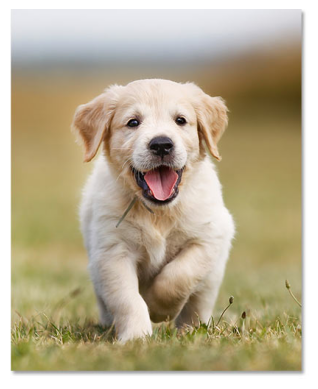

In [7]:
import requests

url = 'https://pe-images.s3.amazonaws.com/basics/cc/image-size-resolution/resize-images-for-print/image-cropped-8x10.jpg'
save_path = os.path.join(inference_dir, 'dog.jpg')

response = requests.get(url)
with open(save_path, 'wb') as f:
    f.write(response.content)

img = Image.open(save_path)
plt.imshow(img)
plt.axis('off')
plt.show()

In [8]:
# Apply the transformation needed
import torchvision.transforms as T

Arg = T.Compose([T.Resize(256),
                 T.CenterCrop(224),
                 T.ToTensor(),
                 T.Normalize(mean = [0.485, 0.456, 0.406],
                             std= [0.229, 0.224, 0.225])])

inp= Arg(img).unsqueeze(0)

In [9]:
# Pass the input through the net
out  = model(inp)['out']
print(out.shape)

torch.Size([1, 21, 224, 224])


In [10]:
import numpy as np
om = torch.argmax(out.squeeze(), dim=0).detach().cpu().numpy()
print(om.shape)
print (np.unique(om))

(224, 224)
[ 0 12]


In [11]:
def decode_segmap(image, nc=21):

  labels_colors = np.array([(0, 0, 0),         # Background
    (128, 0, 0),       # Aeroplane
    (0, 128, 0),       # Bicycle
    (128, 128, 0),     # Bird
    (0, 0, 128),       # Boat
    (128, 0, 128),     # Bottle
    (0, 128, 128),     # Bus
    (128, 128, 128),   # Car
    (64, 0, 0),        # Cat
    (192, 0, 0),       # Chair
    (64, 128, 0),      # Cow
    (192, 128, 0),     # Dining table
    (64, 0, 128),      # Dog
    (192, 0, 128),     # Horse
    (64, 128, 128),    # Motorbike
    (192, 128, 128),   # Person
    (0, 64, 0),        # Potted plant
    (128, 64, 0),      # Sheep
    (0, 192, 0),       # Sofa
    (128, 192, 0),     # Train
    (0, 64, 128),      # TV/Monitor
  ])

  r = np.zeros_like(image).astype(np.uint8)
  g = np.zeros_like(image).astype(np.uint8)
  b = np.zeros_like(image).astype(np.uint8)

  for l in range(0, nc):
    idx = image == l
    r[idx] = labels_colors[l, 0]
    g[idx] = labels_colors[l, 1]
    b[idx] = labels_colors[l, 2]

  rgb = np.stack([r, g, b], axis =2)
  return rgb

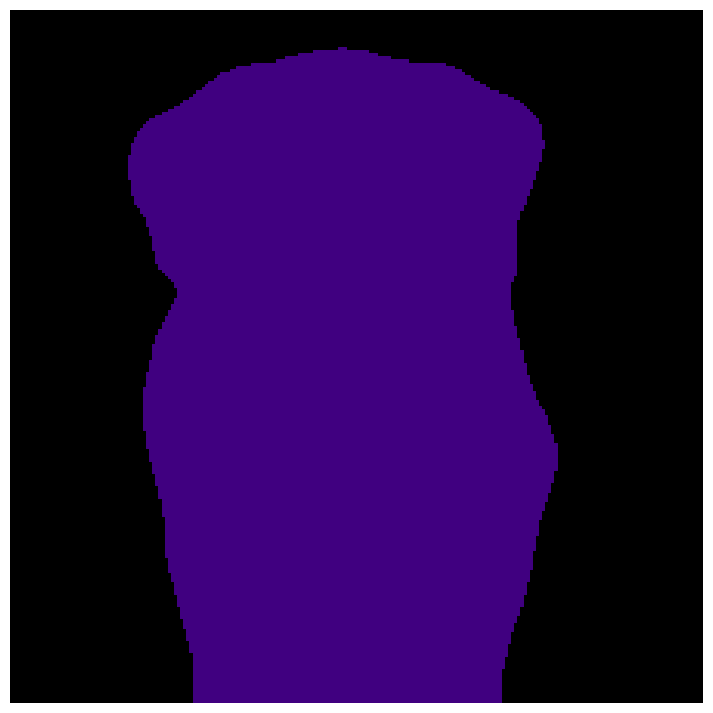

In [12]:
rgb = decode_segmap(om)
plt.figure(figsize=(12, 9))
plt.imshow(rgb)
plt.axis('off')
plt.show()

In [13]:
# one function that can do everything together
def segment(net, path, show_orig=True, dev='cuda'):
  plt.figure(figsize=(10, 7))
  img = Image.open(path)
  if show_orig:
    plt.imshow(img)
    plt.axis('off')
    plt.show()

  # comment the Resize and CenterCrop for better inference results
  trf = T.Compose([T.Resize(640),
                   #T.CenterCrop(224),
                   T.ToTensor(),
                   T.Normalize(mean=[0.485, 0.456, 0.406],
                               std = [0.229, 0.224, 0.225])])

  inp = trf(img).unsqueeze(0).to(dev)
  out =net.to(dev)(inp)['out']
  om = torch.argmax(out.squeeze(), dim=0).detach().cpu().numpy()
  rgb = decode_segmap(om)
  plt.figure(figsize=(10, 7))
  plt.imshow(rgb)
  plt.axis('off')
  plt.show()

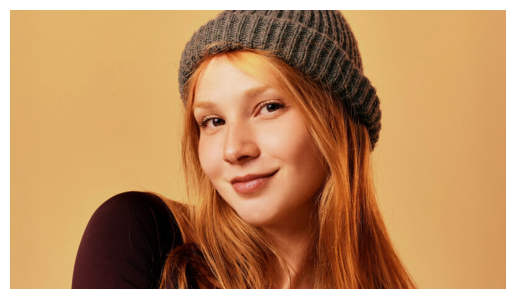

In [14]:
import requests

url = 'https://object.pixocial.com/pixocial/dmxffni837f1xrj8pki9xgrl.jpg'
save_path = os.path.join(inference_dir, 'dog.jpg')

response = requests.get(url)
with open(save_path, 'wb') as f:
    f.write(response.content)

img = Image.open(save_path)
plt.imshow(img)
plt.axis('off')
plt.show()

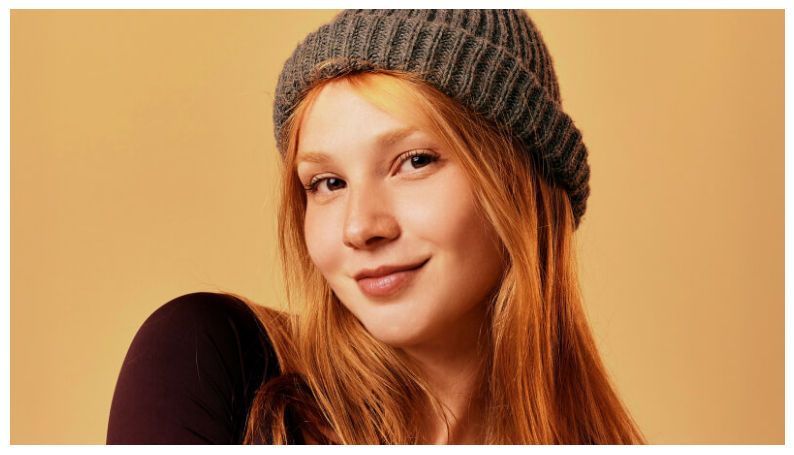

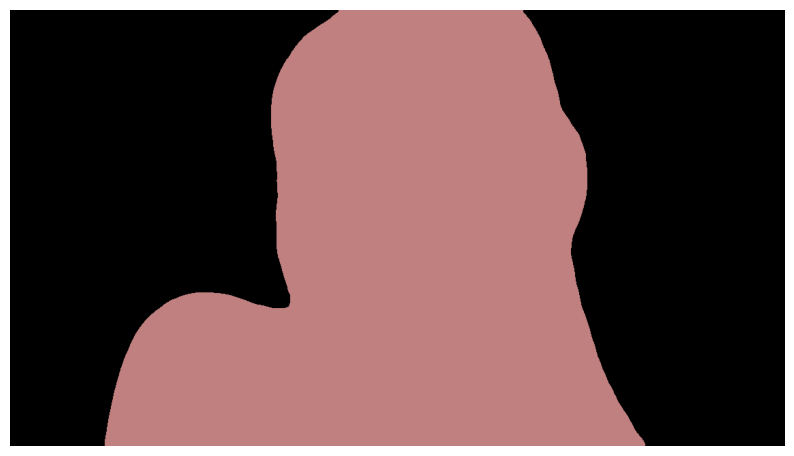

In [15]:
segment(model,os.path.join(inference_dir, 'dog.jpg'), True,'cuda' )

### Using Deeplabv3 as the decoder

In [17]:
dlab = models.segmentation.deeplabv3_resnet101(
    weights='COCO_WITH_VOC_LABELS_V1'
    # pretrained=True
    ).eval()

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:02<00:00, 122MB/s]


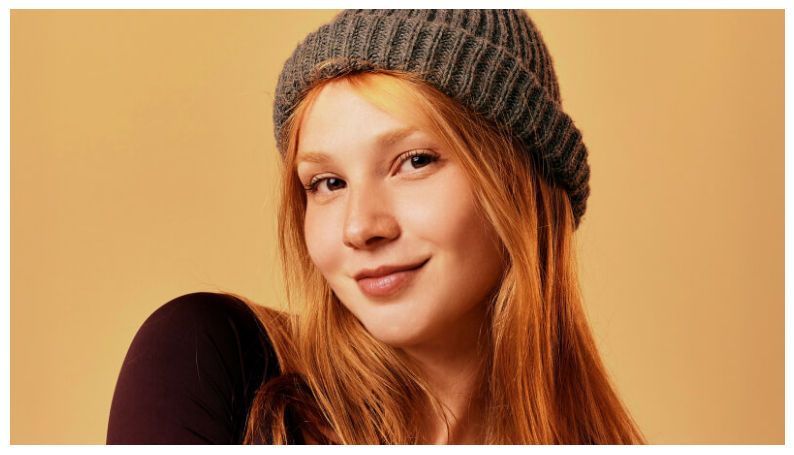

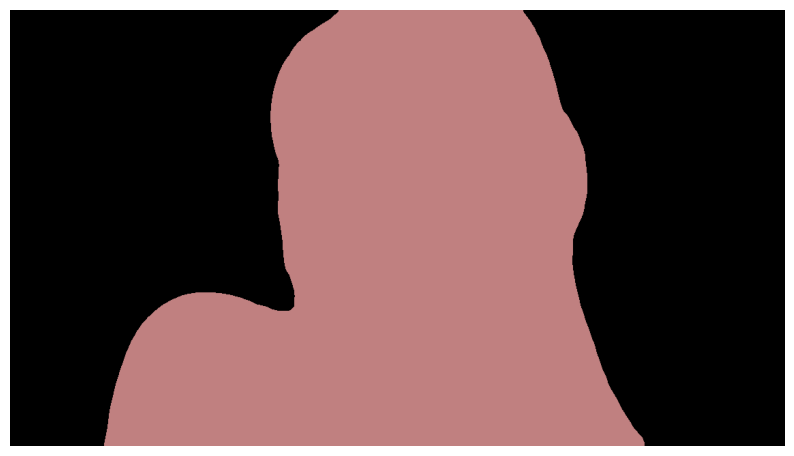

In [18]:
segment(dlab,os.path.join(inference_dir, 'dog.jpg'), True,'cuda' )

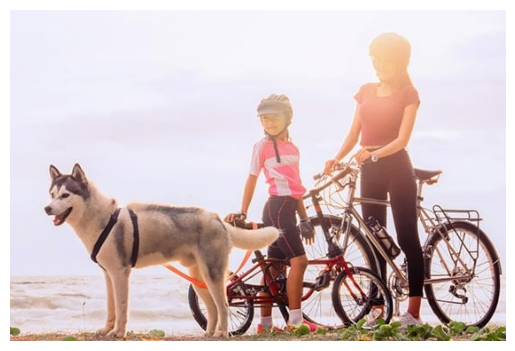

Segmentation Image on FCN


<Figure size 1000x700 with 0 Axes>

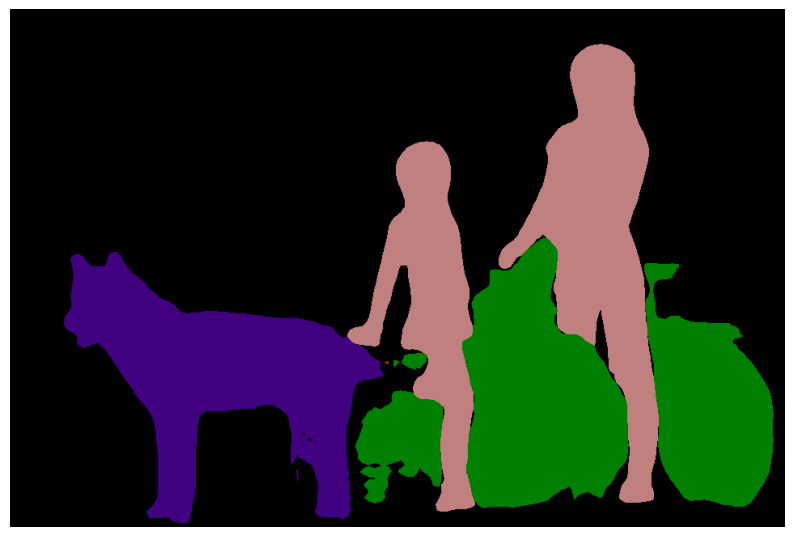

Segmentation Image on dlab


<Figure size 1000x700 with 0 Axes>

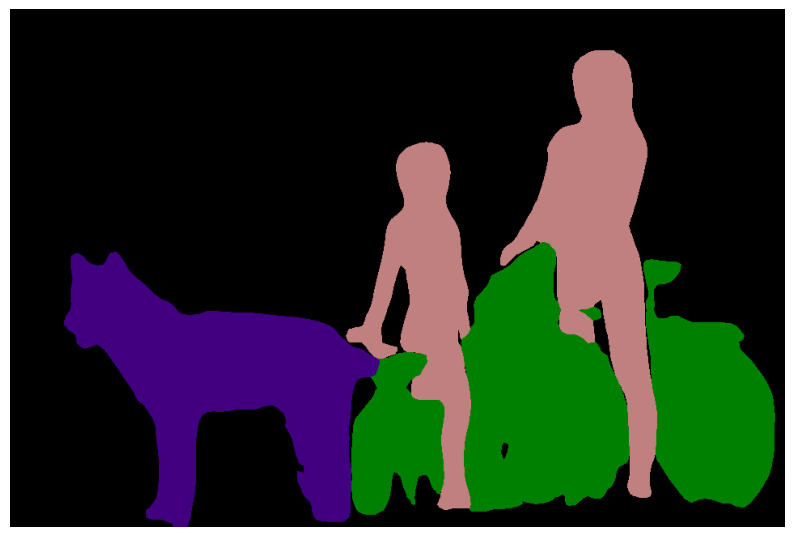

In [25]:
import requests

url = 'https://static.owayo-cdn.com/newhp/img/magazin/cyclingwithdog/cycling-with-dog-alaskan-husky-fast.jpg'
save_path = os.path.join(inference_dir, 'mul.jpg')

response = requests.get(url)
with open(save_path, 'wb') as f:
    f.write(response.content)

img = Image.open(save_path)
plt.imshow(img)
plt.axis('off')
plt.show()

print('Segmentation Image on FCN')
segment(model,os.path.join(inference_dir, 'mul.jpg'), False,'cuda' )

print('Segmentation Image on dlab')
segment(dlab,os.path.join(inference_dir, 'mul.jpg'), False,'cuda' )